In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(os.path.abspath('..'))
import utils

In [2]:
import pandas as pd

In [3]:
url = 'https://ignaciorlando.github.io/datasets/data-science/food.zip'
utils.download(url, 'food.zip')

'food (1).zip'

In [4]:
with zipfile.ZipFile('food.zip', 'r') as zip_ref:
    zip_ref.extractall('df')

NameError: name 'zipfile' is not defined

In [5]:
df = pd.read_csv('df/food_coded.csv')

In [6]:
import matplotlib.pyplot as plt

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           123 non-null    str    
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    str    
 8   comfort_food_reasons          123 non-null    str    
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine                       108 non-null    float64
 13  diet_current    

Inciso a

In [8]:
df['Gender'] = df['Gender'].map({
    1: 'Masculino',
    2: 'Femenino'
})

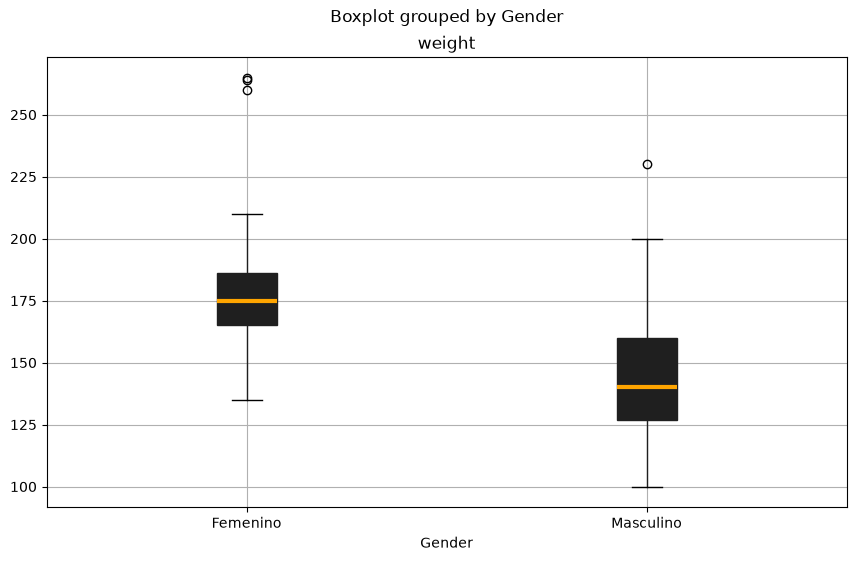

In [9]:
df['weight'] = pd.to_numeric(df['weight'], errors='coerce')
utils.box_plot('Gender', 'weight', df, False, 0)

Inciso b

Estudien la relación entre dos variables cuantitativas.


In [10]:
df['GPA'] = pd.to_numeric(df['GPA'], errors='coerce')

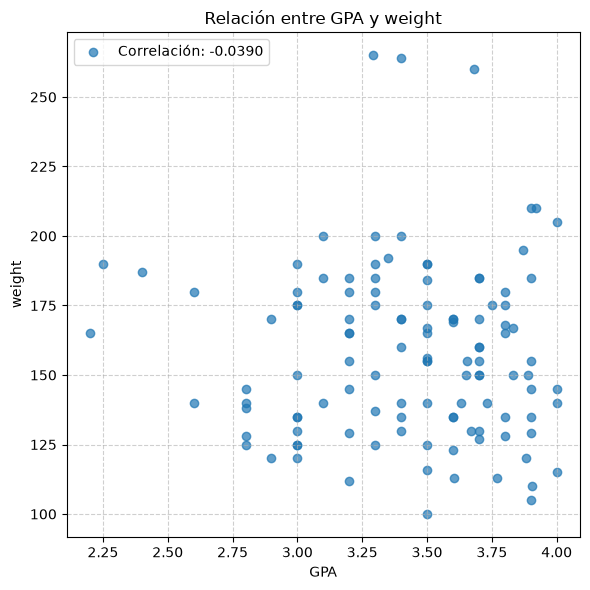

In [11]:
utils.scatter_plot('GPA', 'weight', df)

Podemos ver que no existe relacion lineal de ningun tipo entre el promedio y el peso.

In [ ]:
df.info()

In [45]:
df.head()

,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.400,Femenino,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187.0
1,3.654,Masculino,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155.0
2,3.300,Masculino,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,...,1.0,2.0,5,1165.0,500,none,5,1,900,NaN
3,3.200,Masculino,1,430,3.0,420.0,2,"Pizza, Mac and cheese, ice cream",Boredom,2.0,...,1.0,2.0,5,725.0,690,NaN,3,1,1315,NaN
4,3.500,Masculino,1,720,2.0,420.0,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1.0,...,1.0,1.0,4,940.0,500,Softball,4,2,760,190.0


In [12]:
df['exercise'].value_counts()

exercise
1.0    57
2.0    44
3.0    11
Name: count, dtype: int64

Inciso c

Estudien relaciones entre dos variables cualitativas.


Inciso g

In [13]:
df['exercise'] = df['exercise'].map({
    1: 'Cada dia',
    2: 'Dos o tres veces semanales',
    3: 'Una vez por semana',
    4: 'Algunas veces',
    5: 'Nunca'
})

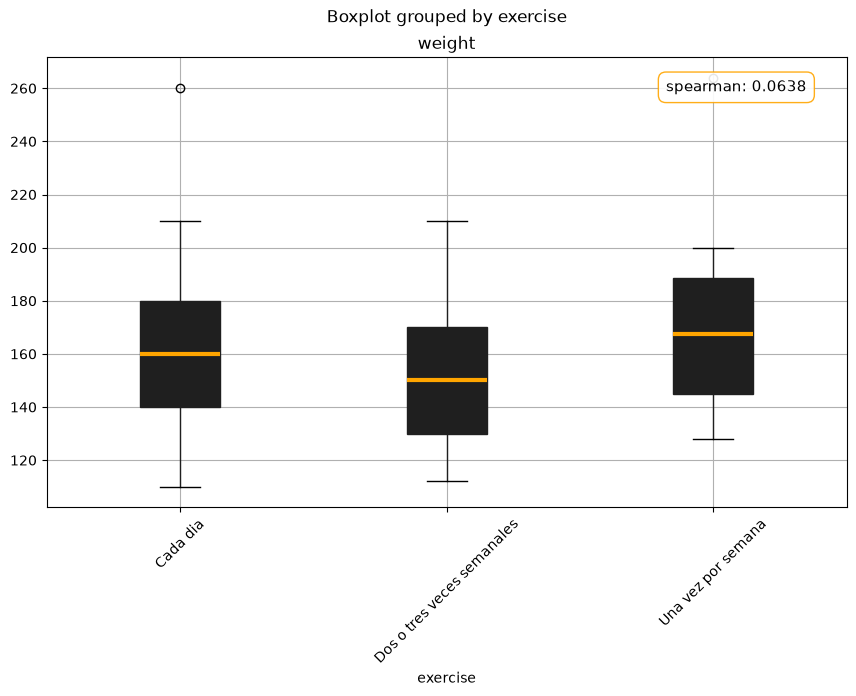

In [14]:
utils.box_plot('exercise', 'weight', df, True, 45)

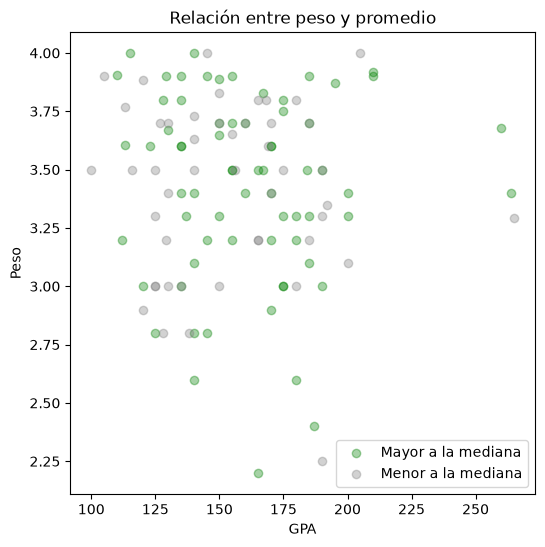

In [20]:
cobro_medio = df['income'].median()

plt.figure(figsize=(6, 6))

country = 'United Kingdom'
color_country = 'red'

cobro_medio_true = df[df['income'] >= cobro_medio]
cobro_medio_false = df[df['income'] < cobro_medio]

plt.scatter(cobro_medio_true['weight'], cobro_medio_true['GPA'], color='green', alpha=0.35, label='Mayor a la mediana')
plt.scatter(cobro_medio_false['weight'], cobro_medio_false['GPA'], color='gray', alpha=0.35, label="Menor a la mediana")

plt.xlabel("GPA")
plt.ylabel("Peso")

# Agregar un título al gráfico
plt.title("Relación entre peso y promedio")

# Agregar leyenda
plt.legend()

# Mostrar el gráfico
plt.show()
